In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading CSV

In [33]:
data = pd.read_csv("youtube recommendation dataset.csv") 
(row,column)=data.shape
print("Number of Rows:",row)
print("Number of Columns:",column)
data.head()

Number of Rows: 1000000
Number of Columns: 14


,user_id,video_id,video_duration,watch_time,liked,commented,subscribed_after,category,device,watch_time_of_day,recommended,clicked,timestamp,watch_percent
0,88263,19387,1499,1499.0,1,0,0,News,TV,Night,0,0,2025-07-16 06:10:54,1.000000
1,46796,5150,2955,2955.0,1,0,0,Education,Mobile,Night,1,1,2024-07-09 10:22:22,1.000000
2,77686,3172,389,389.0,0,0,0,Sports,Desktop,Afternoon,0,0,2025-02-07 09:46:36,1.000000
3,26723,27669,1231,1231.0,1,1,0,Gaming,TV,Evening,0,0,2024-04-28 08:07:13,1.000000
4,55299,24612,3573,353.0,0,1,0,Lifestyle,Desktop,Evening,1,0,2024-03-30 12:54:24,0.098797


# Analyzing the Data

In [34]:
print("Features:",data.columns.tolist())
print("\n")

Features: ['user_id', 'video_id', 'video_duration', 'watch_time', 'liked', 'commented', 'subscribed_after', 'category', 'device', 'watch_time_of_day', 'recommended', 'clicked', 'timestamp', 'watch_percent']




In [35]:
data.describe()

,user_id,video_id,video_duration,watch_time,commented,subscribed_after,recommended,clicked,watch_percent
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1.000000e+06
mean,50014.595087,25008.932584,1911.577131,1283.683469,0.099497,0.050004,0.399768,0.300771,inf
std,28864.277887,14434.546717,3270.284893,2499.074293,0.299328,0.217953,0.489851,0.458594,NaN
min,1.000000,1.000000,0.000000,-299.000000,0.000000,0.000000,0.000000,0.000000,-2.990000e-03
25%,24998.000000,12503.000000,921.000000,498.000000,0.000000,0.000000,0.000000,0.000000,4.990537e-01
50%,50048.000000,25020.000000,1816.000000,1071.000000,0.000000,0.000000,0.000000,0.000000,9.963570e-01
75%,75022.000000,37522.000000,2710.000000,1821.000000,0.000000,0.000000,1.000000,1.000000,1.000000e+00
max,100000.000000,50000.000000,100000.000000,109969.000000,1.000000,1.000000,1.000000,1.000000,inf


In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 14 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   user_id            1000000 non-null  int64  
 1   video_id           1000000 non-null  int64  
 2   video_duration     1000000 non-null  int64  
 3   watch_time         1000000 non-null  float64
 4   liked              997952 non-null   object 
 5   commented          1000000 non-null  int64  
 6   subscribed_after   1000000 non-null  int64  
 7   category           1000000 non-null  object 
 8   device             1000000 non-null  object 
 9   watch_time_of_day  1000000 non-null  object 
 10  recommended        1000000 non-null  int64  
 11  clicked            1000000 non-null  int64  
 12  timestamp          1000000 non-null  object 
 13  watch_percent      1000000 non-null  float64
dtypes: float64(2), int64(7), object(5)
memory usage: 106.8+ MB


In [37]:
data.describe(include="object")

,liked,category,device,watch_time_of_day,timestamp
count,997952,1000000,1000000,1000000,1000000
unique,5,14,4,4,994335
top,0,Comedy,TV,Morning,2025-05-09 15:13:30
freq,696155,124467,250083,250258,3


In [38]:
data.isnull().sum()

user_id                 0
video_id                0
video_duration          0
watch_time              0
liked                2048
commented               0
subscribed_after        0
category                0
device                  0
watch_time_of_day       0
recommended             0
clicked                 0
timestamp               0
watch_percent           0
dtype: int64

In [39]:
data.duplicated().sum()

np.int64(0)

In [40]:
for col in ["liked", "commented", "subscribed_after", "recommended", "clicked", "category","device","watch_time_of_day"]:
    print(col, "->", data[col].unique())

liked -> ['1' '0' 'no' nan 'yes' '2']
commented -> [0 1]
subscribed_after -> [0 1]
recommended -> [0 1]
clicked -> [0 1]
category -> ['News' 'Education' 'Sports' 'Gaming' 'Lifestyle' 'Music' 'Tech' 'Comedy'
 'MUsic' 'gamingg' 'music' 'Ed' 'COMEDY' 'Tech ']
device -> ['TV' 'Mobile' 'Desktop' 'Tablet']
watch_time_of_day -> ['Night' 'Afternoon' 'Evening' 'Morning']


In [41]:
data["liked"].value_counts(dropna=False)

liked
0      696155
1      298845
NaN      2048
2        1007
no        988
yes       957
Name: count, dtype: int64

In [42]:
print((data["watch_time"] < 0).sum())
print((data["video_duration"] == 0).sum())
print((data["video_duration"] == 100000).sum())

500
1000
1000


# Cleaning The Data

In [43]:
data["liked"] = data["liked"].replace({"yes": 1, "no": 0, "1": 1, "0": 0, "2": np.nan})
data["liked"] = pd.to_numeric(data["liked"], errors="coerce")

C:\Users\georg\AppData\Local\Temp\ipykernel_23520\3425308845.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["liked"] = data["liked"].replace({"yes": 1, "no": 0, "1": 1, "0": 0, "2": np.nan})


In [44]:
data["liked"].unique()

array([ 1.,  0., nan])

In [ ]:
data["category"]=data["category"].replace({"music":"Music","MUsic":"Music","Tech ":"Tech","gamingg":"Gaming","Ed":"Education","COMEDY":"Comedy"})?

In [46]:
data["category"].unique()

array(['News', 'Education', 'Sports', 'Gaming', 'Lifestyle', 'Music',
       'Tech', 'Comedy'], dtype=object)

In [ ]:
#Since video duration being of almost 27hrs plus.. seems sus and also howcome the watch time is negative?
mask = data["video_duration"] == 100000
data.loc[mask, ["video_duration", "watch_time"]].describe()

,video_duration,watch_time
count,1000.0,1000.000000
mean,100000.0,52438.406000
std,0.0,52645.838283
min,100000.0,-299.000000
25%,100000.0,-140.000000
50%,100000.0,50000.000000
75%,100000.0,105020.000000
max,100000.0,109969.000000


In [48]:
duration_outlier = data["video_duration"] == 100000
negative_watch = data["watch_time"] < 0

print("video_duration == 100000:", duration_outlier.sum())
print("watch_time < 0:", negative_watch.sum())
print("rows with BOTH problems:", (duration_outlier & negative_watch).sum())
print("negative watch_time but dur NOT 100000:", (~duration_outlier & negative_watch).sum())

video_duration == 100000: 1000
watch_time < 0: 500
rows with BOTH problems: 500
negative watch_time but dur NOT 100000: 0


In [49]:
data = data[data["video_duration"] != 100000]
data = data[data["watch_time"] >= 0]
data = data[data["video_duration"] > 0]

In [50]:
data["timestamp"] = pd.to_datetime(data["timestamp"], errors="coerce")
data = data[data["timestamp"].notna()]

In [51]:
data["watch_percent"] = (data["watch_time"] / data["video_duration"]).clip(upper=1.0)

In [52]:
data.describe()

,user_id,video_id,video_duration,watch_time,liked,commented,subscribed_after,recommended,clicked,timestamp,watch_percent
count,998000.000000,998000.000000,998000.000000,998000.000000,996158.000000,998000.000000,998000.000000,998000.000000,998000.000000,998000,998000.000000
mean,50016.791665,25009.718277,1815.207546,1228.675991,0.300554,0.099501,0.049996,0.399751,0.300791,2024-05-16 23:37:47.141389824,0.749554
min,1.000000,1.000000,30.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2023-01-01 00:01:33,0.001403
25%,24999.000000,12503.000000,922.000000,498.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2023-09-09 00:05:56.750000128,0.499054
50%,50050.000000,25021.000000,1816.000000,1070.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2024-05-17 15:34:48.500000,0.995425
75%,75025.000000,37522.000000,2708.000000,1818.000000,1.000000,0.000000,0.000000,1.000000,1.000000,2025-01-22 16:19:42,1.000000
max,100000.000000,50000.000000,3599.000000,13554.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2025-09-29 23:53:31,1.000000
std,28864.697867,14434.694218,1030.833417,914.346646,0.458499,0.299334,0.217937,0.489847,0.458602,NaN,0.322044


# Descriptive Analysis

In [58]:
data[['watch_time', 'watch_percent', 'video_duration']].describe()
data['watch_percent'].median()
data['video_duration'].std()
data['category'].mode()[0]

data[['liked', 'commented', 'subscribed_after', 'recommended', 'clicked']].mean()

liked               0.300554
commented           0.099501
subscribed_after    0.049996
recommended         0.399751
clicked             0.300791
dtype: float64

In [60]:
data.describe()

,user_id,video_id,video_duration,watch_time,liked,commented,subscribed_after,recommended,clicked,timestamp,watch_percent
count,998000.000000,998000.000000,998000.000000,998000.000000,996158.000000,998000.000000,998000.000000,998000.000000,998000.000000,998000,998000.000000
mean,50016.791665,25009.718277,1815.207546,1228.675991,0.300554,0.099501,0.049996,0.399751,0.300791,2024-05-16 23:37:47.141389824,0.749554
min,1.000000,1.000000,30.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2023-01-01 00:01:33,0.001403
25%,24999.000000,12503.000000,922.000000,498.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2023-09-09 00:05:56.750000128,0.499054
50%,50050.000000,25021.000000,1816.000000,1070.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2024-05-17 15:34:48.500000,0.995425
75%,75025.000000,37522.000000,2708.000000,1818.000000,1.000000,0.000000,0.000000,1.000000,1.000000,2025-01-22 16:19:42,1.000000
max,100000.000000,50000.000000,3599.000000,13554.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2025-09-29 23:53:31,1.000000
std,28864.697867,14434.694218,1030.833417,914.346646,0.458499,0.299334,0.217937,0.489847,0.458602,NaN,0.322044


# Univariate Analysis

### Histogram

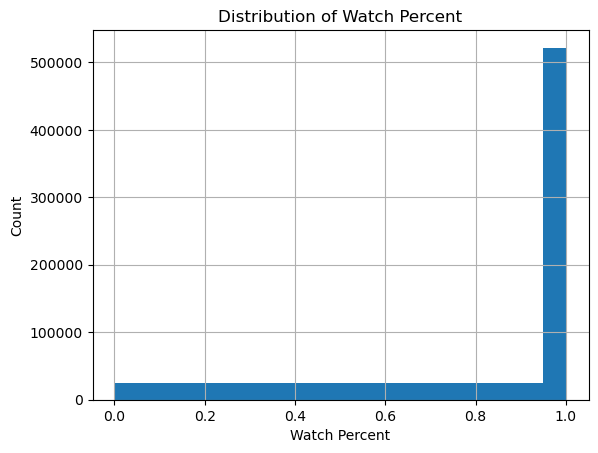

In [63]:
data['watch_percent'].hist(bins=20)
plt.title('Distribution of Watch Percent')
plt.xlabel('Watch Percent')
plt.ylabel('Count')
plt.show()

### Boxplot

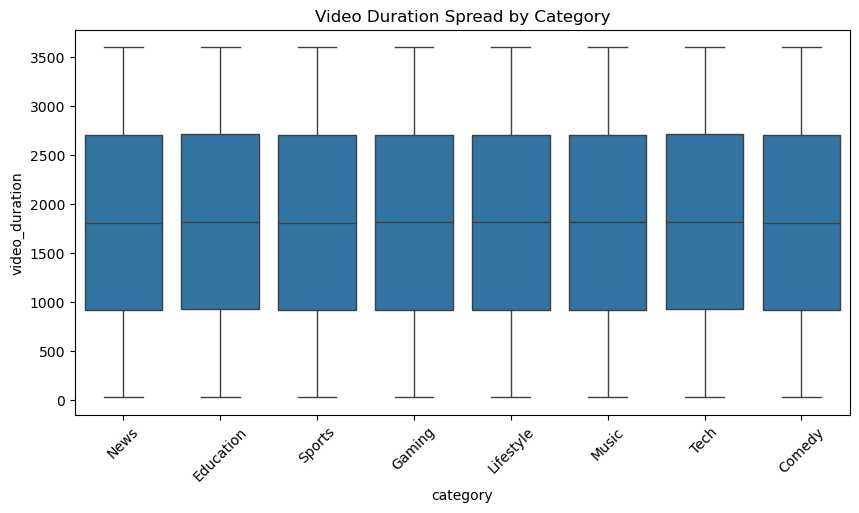

In [64]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x='category', y='video_duration')
plt.xticks(rotation=45)
plt.title('Video Duration Spread by Category')
plt.show()

### Bar Graph

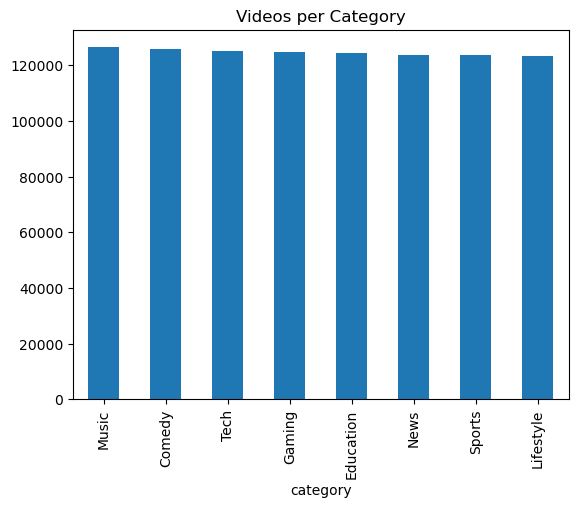

In [65]:
data['category'].value_counts().plot(kind='bar')
plt.title('Videos per Category')
plt.show()

# Bivariate Analysis

### Scatter

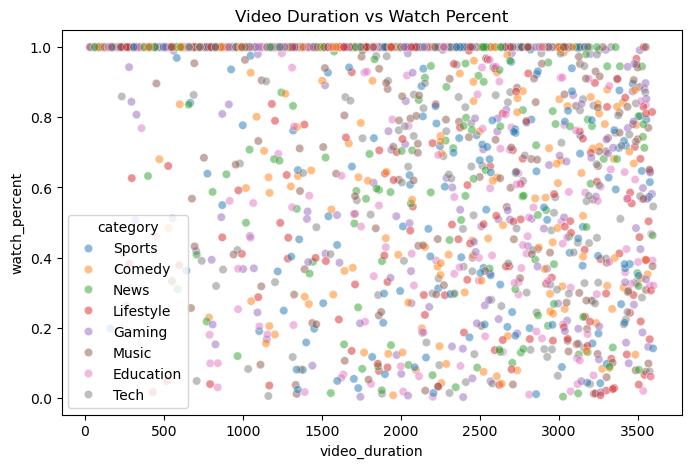

In [72]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data.sample(2000), x='video_duration', y='watch_percent', hue='category', alpha=0.5)
plt.title('Video Duration vs Watch Percent')
plt.show()

### Correlaltion Heatmap

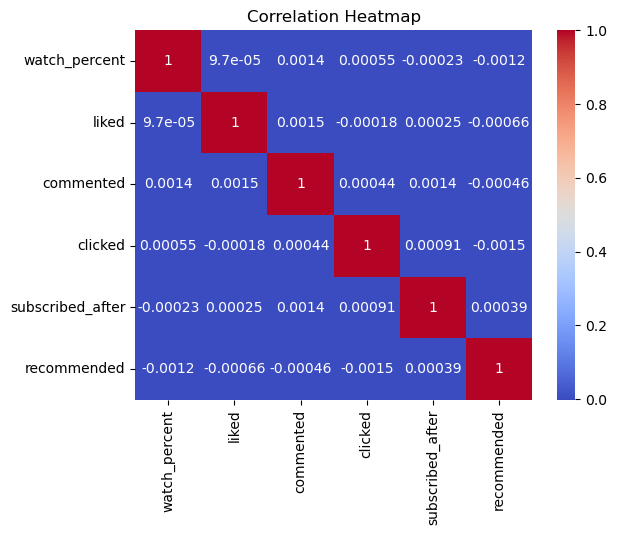

In [73]:
corr_cols = ['watch_percent', 'liked', 'commented', 'clicked', 'subscribed_after', 'recommended']
sns.heatmap(data[corr_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [74]:
#Does recommendation drive engagement?
data.groupby('recommended')['clicked'].mean()
data.groupby('recommended')['watch_percent'].mean()

recommended
0    0.749882
1    0.749063
Name: watch_percent, dtype: float64

In [68]:
#Which category retains attention best?
data.groupby('category')['watch_percent'].mean().sort_values(ascending=False)


category
Music        0.750827
Comedy       0.750391
Education    0.750166
Lifestyle    0.749717
Gaming       0.749561
Tech         0.749487
Sports       0.748801
News         0.747442
Name: watch_percent, dtype: float64

In [69]:
pd.crosstab(data['recommended'], data['clicked'])

clicked,0,1
recommended,,
0,418525,180524
1,279286,119665


# Visualization

### Bar

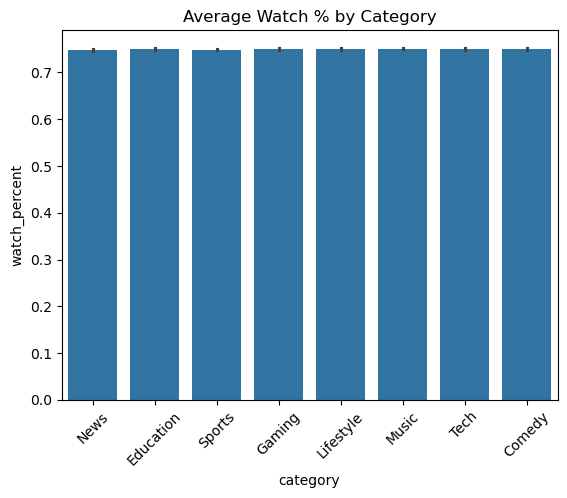

In [77]:
sns.barplot(data=data, x='category', y='watch_percent')
plt.xticks(rotation=45)
plt.title('Average Watch % by Category')
plt.show()

### Line Graph (Trend over time)

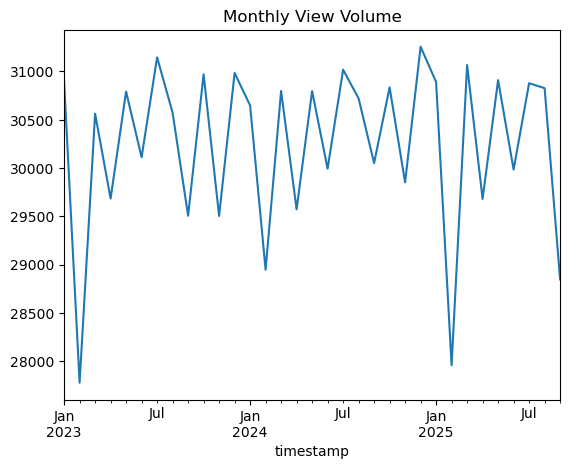

In [76]:
monthly = data.groupby(data['timestamp'].dt.to_period('M')).size()
monthly.plot(kind='line')
plt.title('Monthly View Volume')
plt.show()

### Pie Chart

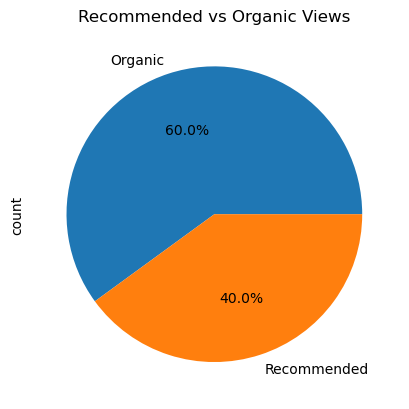

In [75]:
data['recommended'].value_counts().plot(kind='pie', labels=['Organic', 'Recommended'], autopct='%1.1f%%')
plt.title('Recommended vs Organic Views')
plt.show()

# Bonus Features

### Time Series

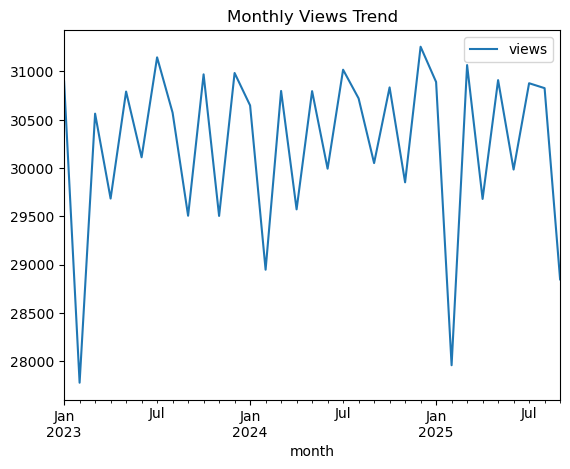

In [79]:
data['month'] = data['timestamp'].dt.to_period('M')
monthly_trend = data.groupby('month').agg(
    views=('video_id', 'count'),
    avg_watch_pct=('watch_percent', 'mean')
)
monthly_trend.plot(y='views', kind='line', title='Monthly Views Trend')
plt.show()

### Feature Engineering (Engagement Features)

In [84]:
data['engagement_score'] = (data['watch_percent'] * 0.4 + data['liked'].fillna(0) * 0.25 + data['clicked'] * 0.2 + data['commented'] * 0.1 + data['subscribed_after'] * 0.05)
data['highly_engaged'] = ((data['watch_percent'] > 0.75) & ((data['liked'] == 1) | (data['commented'] == 1))).astype(int)

### A/B Testing

In [85]:
from scipy import stats
group_a = data[data['recommended'] == 0]['clicked']
group_b = data[data['recommended'] == 1]['clicked']
t_stat, p_value = stats.ttest_ind(group_a, group_b)
print(f"p-value: {p_value:.4f}")

p-value: 0.1347


In [86]:
data.to_csv('youtube_cleaned.csv', index=False)

## Few Insights:
1. Short-form content generates over twice the proportion of highly engaged users compared to long-form content, suggesting that shorter videos are more effective at driving user interaction.
2. Viewer engagement consistently declines as video length increases.
3. Viewer engagement is slightly higher during evenings and nights.